## Data Loading and Feature Engineering

This section loads the historical stock price data for Apple (AAPL) from a CSV file.  
After loading, we examine the initial few rows and inspect the data columns to understand its structure.  

Next, we calculate two important features:  
- **Monthly Return (%)**: Percentage return computed as the relative change from the opening to closing price each month.  
- **Volatility (%)**: A measure of price fluctuation within the month, calculated using the high and low prices normalized by the opening price.  

These features serve as the basis for further analysis of stock performance.


In [8]:

import pandas as pd

df = pd.read_csv(r"C:\Users\indra\OneDrive\Desktop\Stock Analysis Project\data\aapl_us_m.csv")


print("First 5 rows of the data:")
print(df.head())


print("\nColumns and data info:")
print(df.info())


df['Monthly Return (%)'] = ((df['Close'] - df['Open']) / df['Open']) * 100


df['Volatility (%)'] = ((df['High'] - df['Low']) / df['Open']) * 100


print("\nData with Monthly Return and Volatility:")
print(df[['Date', 'Open', 'Close', 'Monthly Return (%)', 'Volatility (%)']].head())


First 5 rows of the data:
         Date      Open      High       Low     Close      Volume
0  1984-09-30  0.099605  0.108938  0.092391  0.094194  2546880223
1  1984-10-31  0.093908  0.102620  0.084546  0.093297  4228540237
2  1984-11-30  0.093908  0.099605  0.082151  0.092687  3999494688
3  1984-12-31  0.092687  0.109845  0.091474  0.109243  4100326793
4  1985-01-31  0.109243  0.116762  0.104720  0.108938  7555493101

Columns and data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    495 non-null    object 
 1   Open    495 non-null    float64
 2   High    495 non-null    float64
 3   Low     495 non-null    float64
 4   Close   495 non-null    float64
 5   Volume  495 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 23.3+ KB
None

Data with Monthly Return and Volatility:
         Date      Open     Close  Monthly R

## Moving Averages, Volume Analysis, and Visualization

In this section, we calculate technical indicators that help understand the stock's price trends and trading activity:
- **Moving Averages (3-month and 6-month)** smooth the closing price to show underlying trends and possible support/resistance levels.
- **12-month Average Volume** provides a baseline for typical trading activity.
- **Volume Spikes** are identified when monthly volume exceeds twice the 12-month average, indicating possible unusual trading interest or events.

The results are then visualized with:
- Closing price alongside moving averages to observe trend directions.
- Monthly volatility to understand price fluctuation magnitude.
- Trading volumes with spikes highlighted to spot months with abnormal trading activity.

These analyses support deeper insights into the stock’s behavior over time.


           Date   Close  MA 3-month  MA 6-month      Volume  \
485  2025-02-28  241.84  242.575333  237.116167   862567069   
486  2025-03-31  222.13  233.237000  235.389833  1115306052   
487  2025-04-30  212.50  225.490000  233.237500  1607318483   
488  2025-05-31  200.85  211.826667  227.201000  1195889556   
489  2025-06-30  205.17  206.173333  219.705167  1100504397   
490  2025-07-31  207.57  204.530000  215.010000  1079935847   
491  2025-08-31  232.14  214.960000  213.393333  1218125232   
492  2025-09-30  254.63  231.446667  218.810000  1265536438   
493  2025-10-31  270.37  252.380000  228.455000  1097142365   
494  2025-11-30  272.95  265.983333  240.471667   428105417   

     Volume 12-month Avg  Volume Spike  
485         1.179175e+09         False  
486         1.152124e+09         False  
487         1.181757e+09         False  
488         1.169596e+09         False  
489         1.117157e+09         False  
490         1.110729e+09         False  
491         1.11842

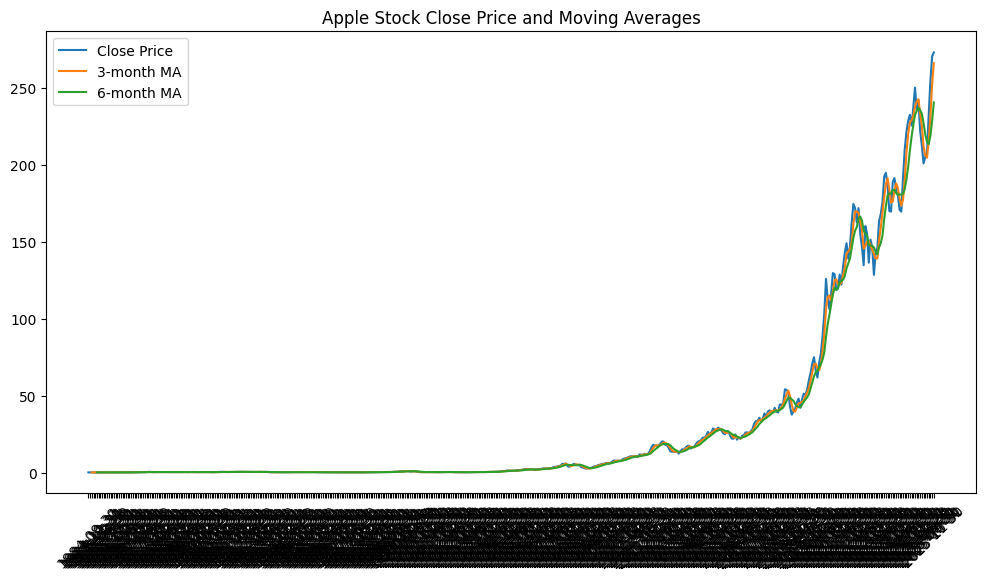

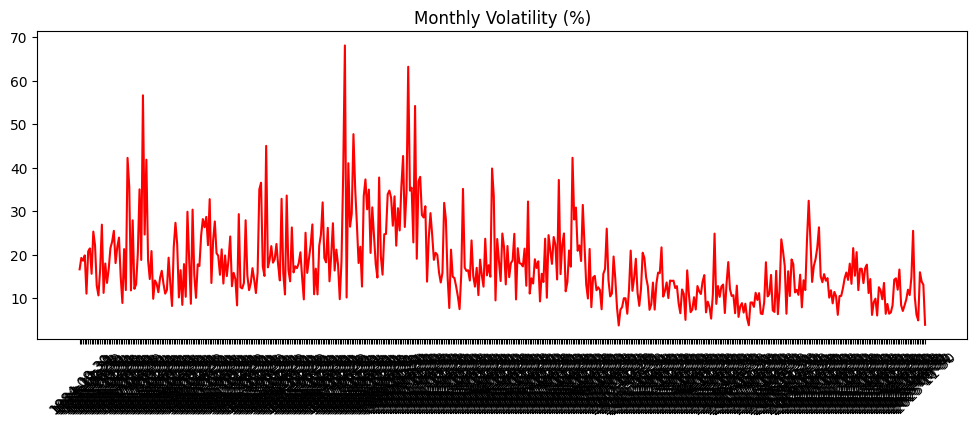

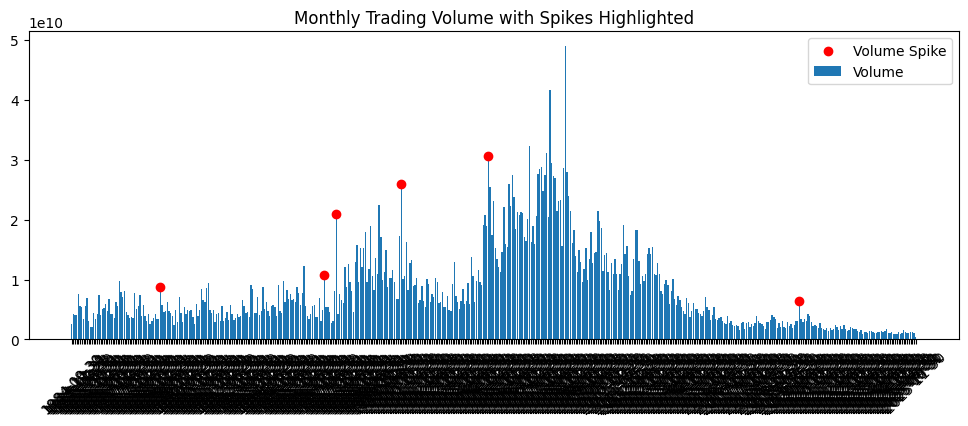

In [10]:
import matplotlib.pyplot as plt

# Calculate 3-month and 6-month moving averages of Close price
df['MA 3-month'] = df['Close'].rolling(window=3).mean()
df['MA 6-month'] = df['Close'].rolling(window=6).mean()

# Calculate 12-month average volume
df['Volume 12-month Avg'] = df['Volume'].rolling(window=12).mean()

# Mark volume spikes where volume is more than twice the 12-month average
df['Volume Spike'] = df['Volume'] > 2 * df['Volume 12-month Avg']

# Show the last 10 rows with new columns
print(df[['Date', 'Close', 'MA 3-month', 'MA 6-month', 'Volume', 'Volume 12-month Avg', 'Volume Spike']].tail(10))

# Plot Close price with Moving Averages
plt.figure(figsize=(12,6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA 3-month'], label='3-month MA')
plt.plot(df['Date'], df['MA 6-month'], label='6-month MA')
plt.xticks(rotation=45)
plt.legend()
plt.title('Apple Stock Close Price and Moving Averages')
plt.show()

# Plot Monthly Volatility
plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Volatility (%)'], color='red')
plt.xticks(rotation=45)
plt.title('Monthly Volatility (%)')
plt.show()

# Plot Volume with spikes highlighted
plt.figure(figsize=(12,4))
plt.bar(df['Date'], df['Volume'], label='Volume')
spike_dates = df[df['Volume Spike'] == True]['Date']
spike_volumes = df[df['Volume Spike'] == True]['Volume']
plt.scatter(spike_dates, spike_volumes, color='red', label='Volume Spike')
plt.xticks(rotation=45)
plt.legend()
plt.title('Monthly Trading Volume with Spikes Highlighted')
plt.show()


In [11]:
# Summary statistics for Monthly Return and Volatility
print(df[['Monthly Return (%)', 'Volatility (%)']].describe())

# Average monthly return and volatility
avg_return = df['Monthly Return (%)'].mean()
avg_volatility = df['Volatility (%)'].mean()

print(f"\nAverage Monthly Return: {avg_return:.2f}%")
print(f"Average Monthly Volatility: {avg_volatility:.2f}%")


       Monthly Return (%)  Volatility (%)
count          495.000000      495.000000
mean             2.229388       17.635253
std             12.026274        8.976831
min            -57.988025        3.713872
25%             -4.321691       11.561662
50%              2.176979       15.509175
75%              9.475685       21.587174
max             45.322468       68.059908

Average Monthly Return: 2.23%
Average Monthly Volatility: 17.64%


## Insights

- Apple’s mean monthly return is 2.23%, showing steady growth over decades.
- Volatility averages 17.64%, meaning monthly price swings are significant for short-term investors.
- Maximum monthly return (45.3%) and drawdown (−58%) show both high potential gains and risks.
- 50% of months had returns between −4.3% and 9.5%.



## Stock Analysis Function

This function `analyze_stock` reads a CSV file containing stock price data and computes key performance metrics:
- **Monthly Return (%)**: The percentage change from the opening to closing price each month.
- **Volatility (%)**: The monthly price range represented as a percentage of the opening price, measuring risk.

It returns the average monthly return and average volatility, providing a summary of the stock's historical performance for easy comparison across multiple stocks.


In [12]:
import os

def analyze_stock(file_path):
    df = pd.read_csv(file_path)
    df['Monthly Return (%)'] = ((df['Close'] - df['Open']) / df['Open']) * 100
    df['Volatility (%)'] = ((df['High'] - df['Low']) / df['Open']) * 100
    avg_return = df['Monthly Return (%)'].mean()
    avg_volatility = df['Volatility (%)'].mean()
    return avg_return, avg_volatility


## Batch Analysis of Multiple Stocks

This code iterates through all CSV files in the specified data directory, applying the `analyze_stock` function to each stock dataset.

It extracts key metrics—average monthly return and average monthly volatility—and aggregates these results into a summarized DataFrame.

This summary provides a convenient overview to compare historical return and risk profiles across multiple stocks.


In [13]:
stocks_dir = r"C:\Users\indra\OneDrive\Desktop\Stock Analysis Project\data"
summary = []

for filename in os.listdir(stocks_dir):
    if filename.endswith(".csv"):
        stock_name = filename.split('_')[0].upper()
        file_path = os.path.join(stocks_dir, filename)
        avg_return, avg_volatility = analyze_stock(file_path)
        summary.append({
            "Stock": stock_name,
            "Average Monthly Return (%)": avg_return,
            "Average Monthly Volatility (%)": avg_volatility
        })

import pandas as pd
summary_df = pd.DataFrame(summary)
print(summary_df)


    Stock  Average Monthly Return (%)  Average Monthly Volatility (%)
0    AAPL                    2.229388                       17.635253
1    AMZN                    3.397404                       21.389109
2     BAC                    1.096520                       14.464190
3     CVX                    1.021922                       10.826662
4   GOOGL                    2.132097                       12.895928
5      GS                    1.151922                       14.026407
6     JNJ                    1.054041                        9.294714
7     JPM                    1.000302                       13.256709
8      KO                    0.884837                        9.337544
9    MSFT                    2.236316                       13.514939
10   NVDA                    3.862003                       24.932793
11    PFE                    0.888314                       11.284566
12    SPY                    0.783867                        6.812807
13    UNH           

## Sorting Stocks by Performance Metrics

To facilitate comparison, the summarized stock data is sorted twice:
- First by **average monthly return** in descending order, highlighting the best performing stocks historically.
- Next by **average monthly volatility** in descending order, identifying the stocks with the highest risk levels.

The sorted tables provide insights into the risk-return tradeoff across the analyzed stock universe.


In [14]:
# Sort stocks by average monthly return
sorted_by_return = summary_df.sort_values(by="Average Monthly Return (%)", ascending=False)
print("Stocks sorted by average monthly return:")
print(sorted_by_return)

# Sort stocks by average monthly volatility
sorted_by_vol = summary_df.sort_values(by="Average Monthly Volatility (%)", ascending=False)
print("Stocks sorted by average monthly volatility:")
print(sorted_by_vol)


Stocks sorted by average monthly return:
    Stock  Average Monthly Return (%)  Average Monthly Volatility (%)
10   NVDA                    3.862003                       24.932793
1    AMZN                    3.397404                       21.389109
9    MSFT                    2.236316                       13.514939
0    AAPL                    2.229388                       17.635253
4   GOOGL                    2.132097                       12.895928
13    UNH                    2.014261                       14.313007
14    WMT                    1.669170                       12.007912
5      GS                    1.151922                       14.026407
2     BAC                    1.096520                       14.464190
6     JNJ                    1.054041                        9.294714
3     CVX                    1.021922                       10.826662
7     JPM                    1.000302                       13.256709
11    PFE                    0.888314            

## Visualizing Average Return and Volatility by Stock

These bar plots visually compare stocks by their:
- Average monthly return, highlighting which stocks have historically delivered higher returns.
- Average monthly volatility, indicating the degree of price fluctuation or risk associated with each stock.

These plots make it easier to assess the risk-return profile of stocks for better portfolio decisions.


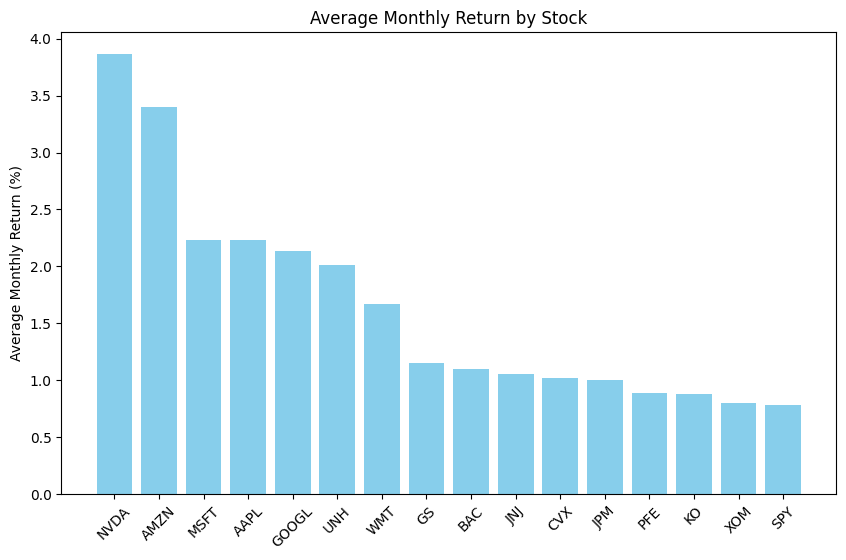

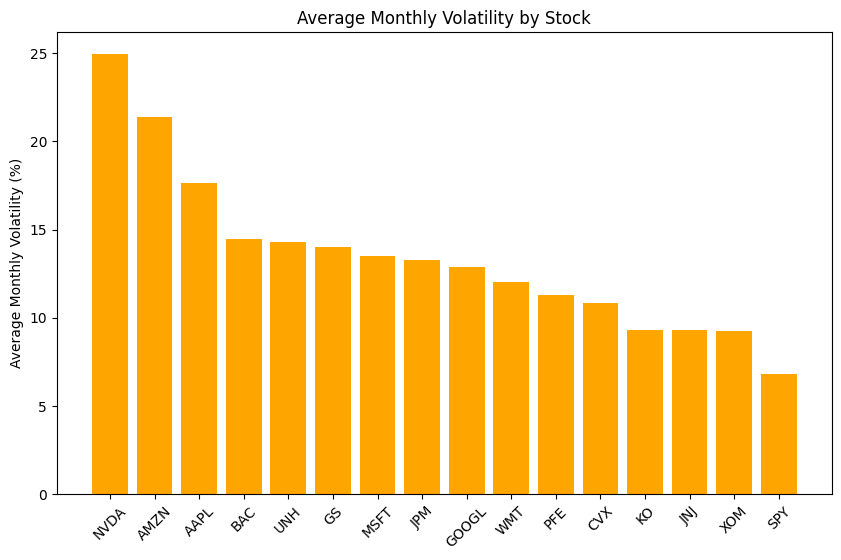

In [15]:
import matplotlib.pyplot as plt

# Bar plot of average monthly returns
plt.figure(figsize=(10,6))
plt.bar(sorted_by_return["Stock"], sorted_by_return["Average Monthly Return (%)"], color='skyblue')
plt.xticks(rotation=45)
plt.ylabel('Average Monthly Return (%)')
plt.title('Average Monthly Return by Stock')
plt.show()

# Bar plot of average monthly volatility
plt.figure(figsize=(10,6))
plt.bar(sorted_by_vol["Stock"], sorted_by_vol["Average Monthly Volatility (%)"], color='orange')
plt.xticks(rotation=45)
plt.ylabel('Average Monthly Volatility (%)')
plt.title('Average Monthly Volatility by Stock')
plt.show()


## Insights from Return & Volatility Comparison

- NVIDIA (NVDA) and Amazon (AMZN) have the highest average monthly returns, but also exhibit the most volatility.
- SPY, XOM, and JNJ are among the most stable stocks, offering lower returns but significantly less risk.
- Apple (AAPL) demonstrates a strong balance of consistent return and manageable volatility, placed near the top in both metrics.
- For most investors, there is a clear risk-return tradeoff: stocks with higher return potential usually have higher volatility.


## Calculating and Sorting by Sharpe Ratio

The Sharpe Ratio measures risk-adjusted return by comparing stock returns relative to their volatility, adjusted for a risk-free rate (set here to 0%).

This metric helps identify stocks that provide better returns for each unit of risk taken.

We compute the Sharpe Ratio for each stock and sort the summary to reveal the ones with the most attractive risk-return tradeoff.


In [16]:
risk_free_rate = 0.0  # Set to 0.0025 for 0.25% monthly risk-free rate, if you want

summary_df['Sharpe Ratio'] = (
    (summary_df['Average Monthly Return (%)'] - risk_free_rate)
    / summary_df['Average Monthly Volatility (%)']
)

# Sort by Sharpe Ratio
sharpe_sorted = summary_df.sort_values(by="Sharpe Ratio", ascending=False)
print(sharpe_sorted)


    Stock  Average Monthly Return (%)  Average Monthly Volatility (%)  \
9    MSFT                    2.236316                       13.514939   
4   GOOGL                    2.132097                       12.895928   
1    AMZN                    3.397404                       21.389109   
10   NVDA                    3.862003                       24.932793   
13    UNH                    2.014261                       14.313007   
14    WMT                    1.669170                       12.007912   
0    AAPL                    2.229388                       17.635253   
12    SPY                    0.783867                        6.812807   
6     JNJ                    1.054041                        9.294714   
8      KO                    0.884837                        9.337544   
3     CVX                    1.021922                       10.826662   
15    XOM                    0.805878                        9.263881   
5      GS                    1.151922              

## Average Monthly Return & Volatility Insights

- NVIDIA (NVDA) and Amazon (AMZN) have delivered the highest average monthly returns, while also exhibiting significant volatility.
- Microsoft (MSFT), Google (GOOGL), and Apple (AAPL) maintain strong balance between returns and volatility, indicating consistent long-term growth with moderate risk.
- Stocks and ETFs like SPY, JNJ, KO, XOM, and CVX display lower returns and lower volatility, suitable for risk-averse or income-focused investors.
- Financial sector stocks (GS, BAC, JPM) tend to show lower returns and moderate volatility, reflecting sector-specific risk and reward characteristics.
- There is a clear tradeoff between return and risk: stocks with higher reward potential generally display greater volatility.


## Visualizing Sharpe Ratios

The bar plot below visualizes stocks ranked by their Sharpe Ratios, emphasizing those with the best risk-adjusted returns.

A higher Sharpe Ratio indicates a more attractive tradeoff between return and volatility, which aids in portfolio selection decisions.


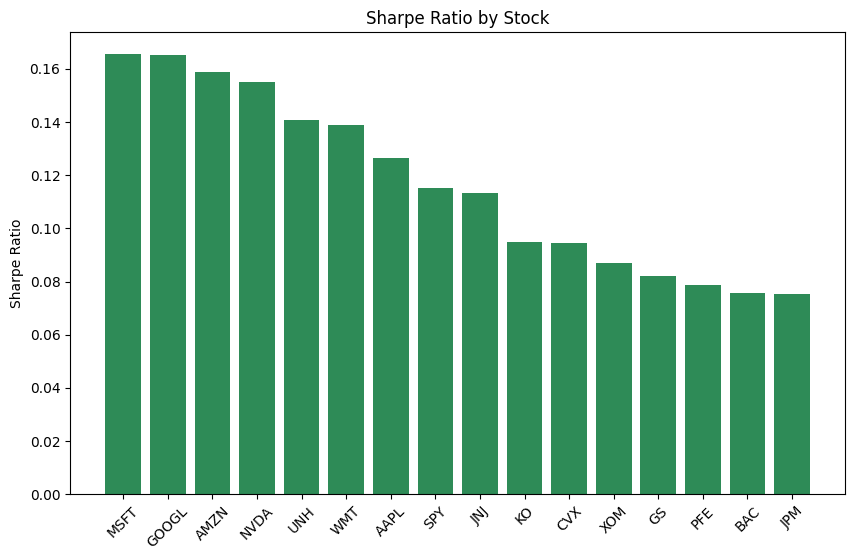

In [17]:
plt.figure(figsize=(10,6))
plt.bar(sharpe_sorted["Stock"], sharpe_sorted["Sharpe Ratio"], color='seagreen')
plt.xticks(rotation=45)
plt.ylabel('Sharpe Ratio')
plt.title('Sharpe Ratio by Stock')
plt.show()


## Sharpe Ratio & Risk-Adjusted Performance Insights

- MSFT and GOOGL top the list for risk-adjusted returns, with the highest Sharpe ratios of the analyzed stocks.
- AMZN and NVDA maintain strong Sharpe ratios, indicating that their high returns outweigh their high volatility for long-term growth-oriented investors.
- AAPL, WMT, and UNH offer a balanced profile of risk and reward, suitable for diversified portfolios.
- SPY, JNJ, KO, and XOM are valuable for stability and capital preservation, reflected by lower Sharpe ratios.
- Financial sector stocks (GS, BAC, JPM) display the lowest Sharpe ratios, emphasizing the need for cautious allocation in volatile market conditions.
- Consistently high Sharpe ratios identify stocks where returns most efficiently compensate for risk taken, providing key guidance for constructing a diversified portfolio.


## Computing Expected Portfolio Performance

This code calculates the expected performance of an equally weighted portfolio using the stocks analyzed.

- Each stock is assigned an equal weight in the portfolio.
- The expected portfolio return is computed as the sum of weighted average monthly returns.
- Portfolio volatility is approximated assuming zero correlation between stocks by aggregating weighted volatilities.
- The Sharpe ratio provides an estimate of risk-adjusted portfolio return.

This analysis gives a baseline understanding of portfolio characteristics before advanced optimization considering correlations and covariances.


In [18]:
import numpy as np


weights = np.array([1/len(summary_df)]*len(summary_df))


portfolio_return = np.sum(weights * summary_df['Average Monthly Return (%)'])


portfolio_volatility = np.sqrt(np.sum((weights**2) * (summary_df['Average Monthly Volatility (%)']**2)))


portfolio_sharpe = portfolio_return / portfolio_volatility

print(f"Expected Portfolio Monthly Return: {portfolio_return:.2f}%")
print(f"Expected Portfolio Monthly Volatility: {portfolio_volatility:.2f}%")
print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.2f}")


Expected Portfolio Monthly Return: 1.64%
Expected Portfolio Monthly Volatility: 3.55%
Portfolio Sharpe Ratio: 0.46


## Preparing Combined Monthly Returns Dataframe

This code block reads each stock's CSV file from the data directory, calculates the monthly returns as percentage change between closing and opening prices, and stores them in individual DataFrames.

All stock return DataFrames are merged on the 'Date' column to form a consolidated DataFrame where each column represents the monthly returns of one stock indexed by the date.

The resulting structure facilitates portfolio-level analyses that require synchronized historical returns across stocks.


In [19]:
import pandas as pd
import os

# Directory of your data
stocks_dir = r"C:\Users\indra\OneDrive\Desktop\Stock Analysis Project\data"

# Dictionary to store individual stock DataFrames
stock_dfs = {}

for filename in os.listdir(stocks_dir):
    if filename.endswith(".csv"):
        stock_name = filename.split('_')[0].upper()
        file_path = os.path.join(stocks_dir, filename)
        df = pd.read_csv(file_path)
        # Calculate monthly return (%) using close and open prices
        df['Monthly Return (%)'] = ((df['Close'] - df['Open']) / df['Open']) * 100
        stock_dfs[stock_name] = df[['Date', 'Monthly Return (%)']].copy()

# Merge all stocks on Date to create a single DataFrame of returns
merged_returns = None
for stock, df in stock_dfs.items():
    if merged_returns is None:
        merged_returns = df.rename(columns={'Monthly Return (%)': stock})
    else:
        merged_returns = merged_returns.merge(df.rename(columns={'Monthly Return (%)': stock}), on='Date', how='outer')

# Set Date as index and sort
merged_returns['Date'] = pd.to_datetime(merged_returns['Date'])
merged_returns = merged_returns.set_index('Date').sort_index()

# Preview
print(merged_returns.head())


            AAPL  AMZN  BAC       CVX  GOOGL  GS        JNJ        JPM  \
Date                                                                     
1970-01-31   NaN   NaN  NaN -9.628123    NaN NaN -11.979741  -4.534595   
1970-02-28   NaN   NaN  NaN  5.896167    NaN NaN   0.000000  15.772077   
1970-03-31   NaN   NaN  NaN -7.753376    NaN NaN  -3.049761  -1.213240   
1970-04-30   NaN   NaN  NaN -4.870445    NaN NaN  -7.828746 -11.334078   
1970-05-31   NaN   NaN  NaN  5.119803    NaN NaN  -8.446813  -8.324279   

                  KO  MSFT  NVDA  PFE  SPY  UNH  WMT       XOM  
Date                                                            
1970-01-31 -3.532456   NaN   NaN  NaN  NaN  NaN  NaN -8.642587  
1970-02-28  4.847982   NaN   NaN  NaN  NaN  NaN  NaN -4.115359  
1970-03-31 -3.443238   NaN   NaN  NaN  NaN  NaN  NaN  5.535557  
1970-04-30 -7.828321   NaN   NaN  NaN  NaN  NaN  NaN -6.968998  
1970-05-31 -3.262261   NaN   NaN  NaN  NaN  NaN  NaN  6.260703  


## Covariance Matrix of Stock Returns

This block calculates the covariance matrix for the monthly returns of all stocks in the merged returns DataFrame.

- Covariance quantifies the degree to which two stocks move together.
- Diagonal elements represent each stock’s return variance (risk).
- Off-diagonal elements capture pairwise correlations needed for portfolio optimization and diversification analysis.

The resulting matrix is a foundational input for calculating portfolio variance and constructing efficient frontiers.


In [20]:
cov_matrix = merged_returns.cov()
print(cov_matrix)


             AAPL        AMZN         BAC        CVX      GOOGL         GS  \
AAPL   144.631265   63.414820   27.290370  16.714163  38.858933  43.382753   
AMZN    63.414820  268.939937   29.861035  22.676313  35.959246  34.854345   
BAC     27.290370   29.861035  113.858041  22.447908  21.987518  52.821671   
CVX     16.714163   22.676313   22.447908  47.045648  14.662853  23.230829   
GOOGL   38.858933   35.959246   21.987518  14.662853  74.611643  33.963425   
GS      43.382753   34.854345   52.821671  23.230829  33.963425  84.185779   
JNJ     13.997957   13.190974   18.732529  10.313082   6.921539   9.992623   
JPM     25.771056   41.299852   66.981140  18.493265  19.766636  53.216415   
KO       9.056513    8.125020   16.580703   9.796781   7.088919   8.838259   
MSFT    48.404659   60.264993   27.958455  14.711652  26.142712  31.587489   
NVDA    93.361342   91.209981   39.560118  27.167428  42.815863  53.120441   
PFE      9.153764   18.936432   23.803404  11.851292   6.947838 

## Covariance Matrix of Stock Returns

This block calculates the covariance matrix for the monthly returns of all stocks in the merged returns DataFrame.

- Covariance quantifies the degree to which two stocks move together.
- Diagonal elements represent each stock’s return variance (risk).
- Off-diagonal elements capture pairwise correlations needed for portfolio optimization and diversification analysis.

The resulting matrix is a foundational input for calculating portfolio variance and constructing efficient frontiers.


In [21]:
import numpy as np


num_stocks = len(merged_returns.columns)
weights = np.array([1/num_stocks] * num_stocks)


portfolio_variance = weights.T.dot(cov_matrix).dot(weights)


portfolio_volatility = np.sqrt(portfolio_variance)

print(f"Portfolio Expected Monthly Volatility (considering correlations): {portfolio_volatility:.4f}%")


Portfolio Expected Monthly Volatility (considering correlations): 5.1555%


## Calculating Portfolio Expected Return with Correlations

This section calculates the expected portfolio monthly return by taking the weighted average of each stock's mean monthly return.

Combined with the previously calculated portfolio volatility (which includes correlations), these metrics provide a clear risk-return profile for the equally weighted portfolio.

These serve as the foundation for further portfolio optimization or risk management analyses.


In [22]:

mean_returns = merged_returns.mean()

portfolio_return = np.sum(weights * mean_returns)

print(f"Expected Portfolio Monthly Return: {portfolio_return:.4f}%")


Expected Portfolio Monthly Return: 1.6393%


## Calculating Portfolio Sharpe Ratio

The Sharpe ratio is computed to assess the portfolio’s risk-adjusted return.

- It represents how much excess return (over risk-free rate) is earned per unit of risk (volatility).
- This metric helps investors compare performance accounting for risk, guiding portfolio decisions.


In [23]:
risk_free_rate = 0.0  

portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_volatility
print(f"Portfolio Sharpe Ratio: {portfolio_sharpe:.4f}")


Portfolio Sharpe Ratio: 0.3180


## Visualizing Portfolio Cumulative Returns

This section calculates the cumulative returns of the equally weighted portfolio over time.

- Missing returns are safely handled by filling with zeros.
- Monthly portfolio returns are aggregated using stock weights.
- The cumulative return series demonstrates how the portfolio value would have evolved, starting at 100.

The plot provides an intuitive visual of long-term portfolio performance and growth trends.


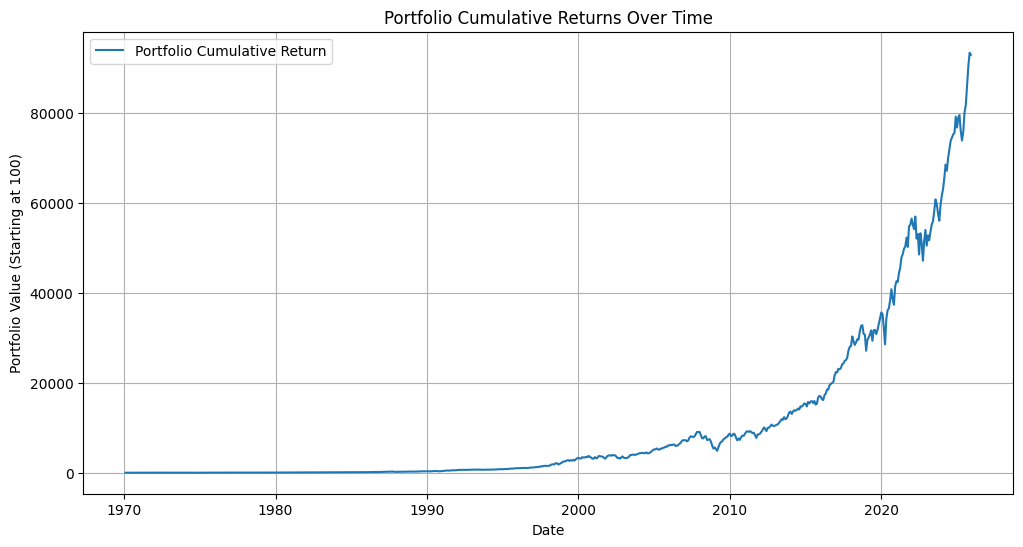

In [24]:
import matplotlib.pyplot as plt


returns_filled = merged_returns.fillna(0)


portfolio_returns = returns_filled.dot(weights)


cum_returns = (1 + portfolio_returns / 100).cumprod() * 100

plt.figure(figsize=(12,6))
plt.plot(cum_returns.index, cum_returns, label='Portfolio Cumulative Return')
plt.title('Portfolio Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (Starting at 100)')
plt.legend()
plt.grid(True)
plt.show()


## Portfolio Maximum Drawdown Analysis and Visualization

Maximum drawdown is the largest observed loss from a peak portfolio value to a subsequent trough before a new peak.

This measure is crucial to assess downside risk and help investors understand potential losses during market downturns.

The accompanying plot shows the portfolio's drawdown over time, highlighting periods of significant decline and recovery.


Maximum Drawdown: -46.01%


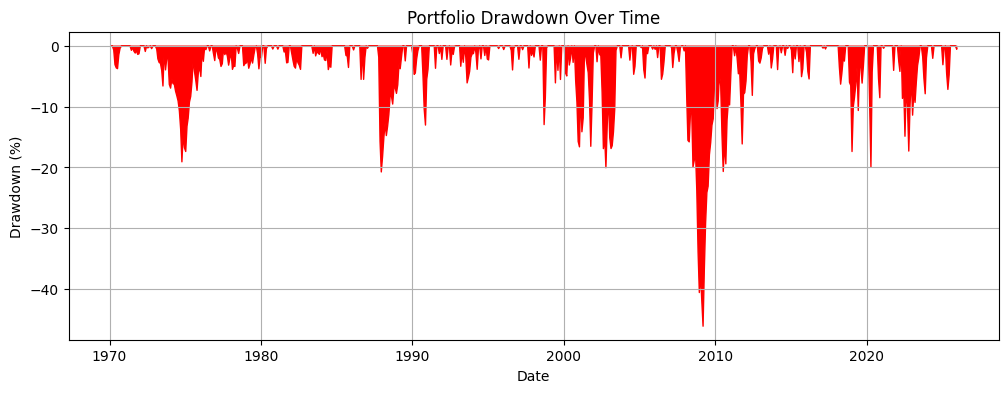

In [25]:

running_max = cum_returns.cummax()


drawdown = (cum_returns - running_max) / running_max * 100


max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2f}%")


plt.figure(figsize=(12,4))
plt.fill_between(drawdown.index, drawdown, color='red')
plt.title('Portfolio Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True)
plt.show()


## Portfolio Optimization to Maximize Sharpe Ratio

This section uses constrained optimization to find the portfolio weights that maximize the Sharpe ratio, representing the best risk-adjusted return.

- The objective function minimizes the negative Sharpe ratio given expected returns and covariance matrix.
- Constraints ensure weights sum to 1 and no short-selling is allowed (weights between 0 and 1).
- The optimization algorithm (SLSQP) searches for the optimal portfolio allocation.
- Results include optimal weights, expected portfolio return, volatility, and Sharpe ratio.

This approach provides a systematic method to construct an efficient portfolio tailored to maximize reward per unit of risk.


In [27]:
import scipy.optimize as sco

# Mean returns and covariance
mean_returns = merged_returns.mean()
cov_matrix = merged_returns.cov()

# Objective: Maximize Sharpe Ratio (maximize return / volatility)
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.sum(weights * mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, vol

def neg_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate=0.0):
    ret, vol = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free_rate)/vol

# Constraints: Sum of weights == 1
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

# Bounds for weights between 0 and 1 (no short selling)
bounds = tuple((0,1) for _ in range(len(mean_returns)))

# Initial guess (equal weights)
init_guess = np.array(len(mean_returns) * [1. / len(mean_returns)])

# Optimize
opt = sco.minimize(neg_sharpe_ratio, init_guess,
                   args=(mean_returns, cov_matrix),
                   method='SLSQP', bounds=bounds,
                   constraints=constraints)

optimal_weights = opt.x
optimal_ret, optimal_vol = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
optimal_sharpe = (optimal_ret) / optimal_vol

print("Optimal Portfolio Weights:")
for stock, weight in zip(mean_returns.index, optimal_weights):
    print(f"{stock}: {weight:.4f}")

print(f"\nOptimal Expected Return: {optimal_ret:.4f}%")
print(f"Optimal Portfolio Volatility: {optimal_vol:.4f}%")
print(f"Optimal Sharpe Ratio: {optimal_sharpe:.4f}")


Optimal Portfolio Weights:
AAPL: 0.0000
AMZN: 0.0664
BAC: 0.0000
CVX: 0.0000
GOOGL: 0.2191
GS: 0.0000
JNJ: 0.0980
JPM: 0.0000
KO: 0.0187
MSFT: 0.1016
NVDA: 0.0849
PFE: 0.0000
SPY: 0.0000
UNH: 0.2280
WMT: 0.1471
XOM: 0.0362

Optimal Expected Return: 2.1015%
Optimal Portfolio Volatility: 5.4217%
Optimal Sharpe Ratio: 0.3876


## Visualizing Optimized Portfolio Cumulative Returns

This section visualizes the growth of the portfolio constructed with the optimized weights obtained from the Sharpe ratio maximization.

- Portfolio returns are aggregated using the optimal weights.
- Cumulative returns are computed to simulate portfolio value growth.
- The plot reveals how the optimized portfolio performs over time compared to other allocations.

This visualization helps validate the effectiveness of the optimization in improving portfolio performance.


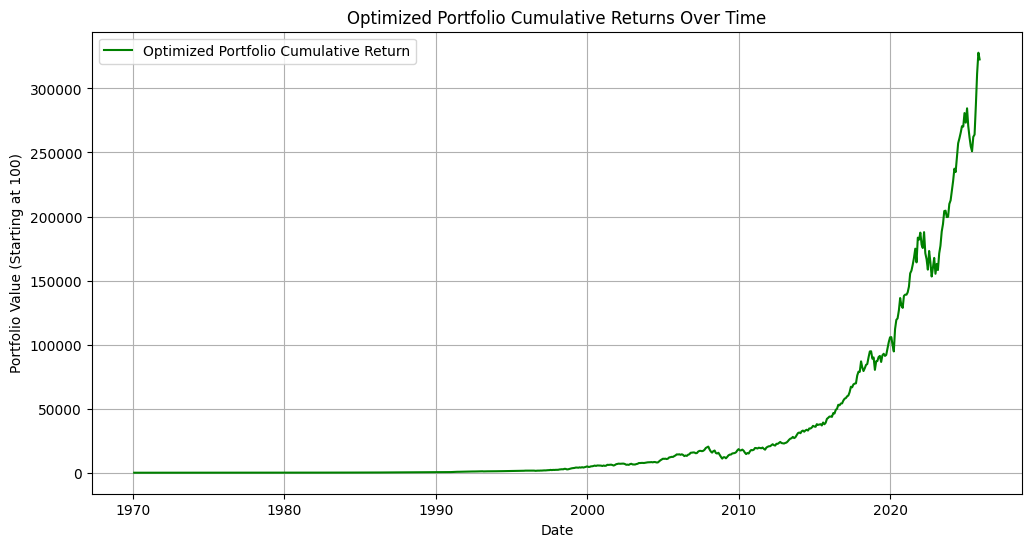

In [28]:

optimized_portfolio_returns = returns_filled.dot(optimal_weights)


optimized_cum_returns = (1 + optimized_portfolio_returns / 100).cumprod() * 100


plt.figure(figsize=(12,6))
plt.plot(optimized_cum_returns.index, optimized_cum_returns, label='Optimized Portfolio Cumulative Return', color='green')
plt.title('Optimized Portfolio Cumulative Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (Starting at 100)')
plt.legend()
plt.grid(True)
plt.show()


## Optimized Portfolio Drawdown Analysis

This segment calculates and visualizes maximum drawdown for the optimized portfolio, showing peak-to-trough declines over time.

- Maximum drawdown quantifies the worst loss from peak value, measuring downside risk.
- The filled plot visualizes drawdown periods to highlight risk and recovery patterns.

This risk assessment complements earlier return and volatility evaluations, essential for comprehensive portfolio understanding.


Optimized Portfolio Maximum Drawdown: -45.79%


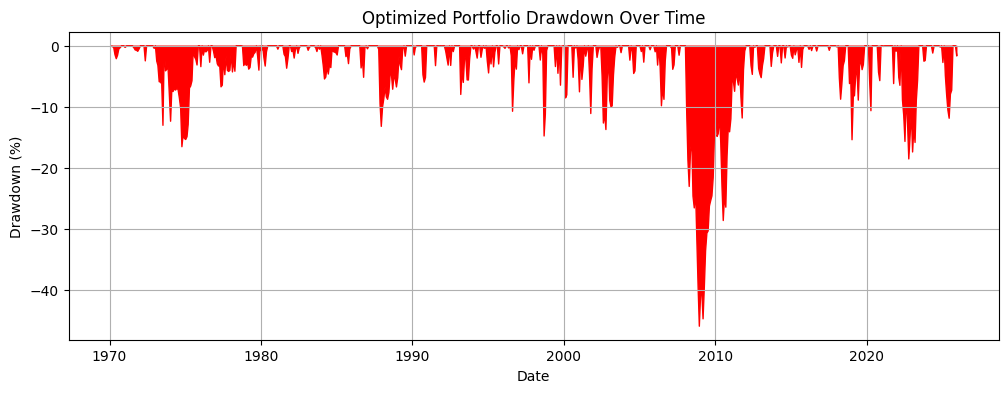

In [29]:

running_max_opt = optimized_cum_returns.cummax()


drawdown_opt = (optimized_cum_returns - running_max_opt) / running_max_opt * 100


max_drawdown_opt = drawdown_opt.min()
print(f"Optimized Portfolio Maximum Drawdown: {max_drawdown_opt:.2f}%")


plt.figure(figsize=(12,4))
plt.fill_between(drawdown_opt.index, drawdown_opt, color='red')
plt.title('Optimized Portfolio Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.grid(True)
plt.show()


## Scenario Analysis during Major Financial Crises

This section evaluates the optimized portfolio's resilience during significant market downturns:

- Portfolio cumulative returns are visualized for the 2008 Financial Crisis and the COVID-19 crash periods.
- Maximum drawdowns during these turbulent times are calculated to quantify downside risk.
  
Such scenario analysis provides valuable insights into portfolio robustness under stress conditions and highlights potential vulnerabilities.


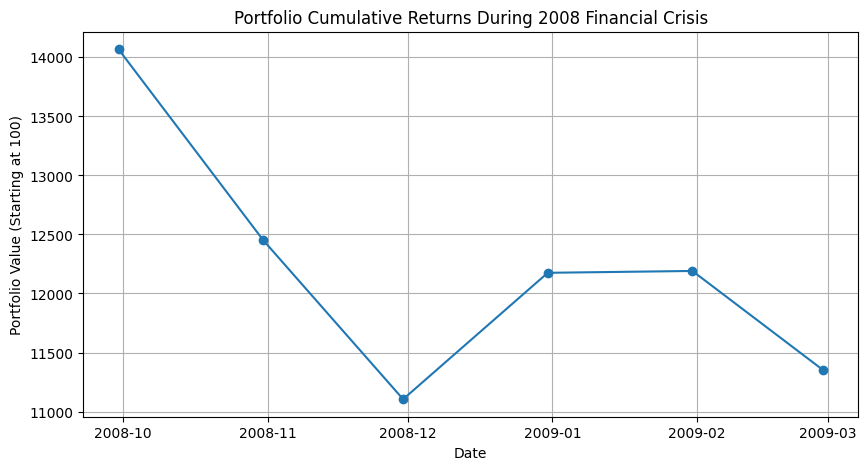

Maximum Drawdown during 2008 Financial Crisis: -21.07%


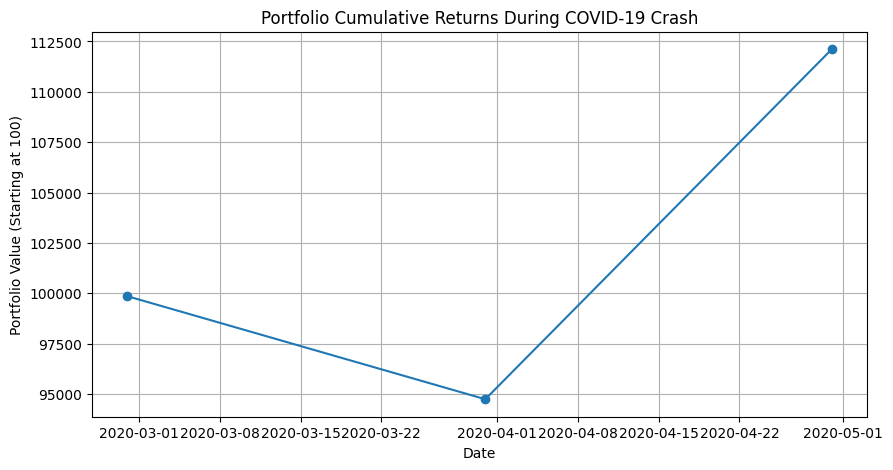

Maximum Drawdown during COVID-19 Crash: -5.12%


In [30]:

crisis_periods = {
    "2008 Financial Crisis": ("2008-09-01", "2009-03-01"),
    "COVID-19 Crash": ("2020-02-01", "2020-04-30")
}


for name, (start, end) in crisis_periods.items():
    scenario_returns = optimized_cum_returns.loc[start:end]
    
    plt.figure(figsize=(10,5))
    plt.plot(scenario_returns.index, scenario_returns, marker='o', linestyle='-')
    plt.title(f"Portfolio Cumulative Returns During {name}")
    plt.xlabel('Date')
    plt.ylabel('Portfolio Value (Starting at 100)')
    plt.grid(True)
    plt.show()
    
   
    running_max_scenario = scenario_returns.cummax()
    drawdown_scenario = (scenario_returns - running_max_scenario) / running_max_scenario * 100
    max_dd = drawdown_scenario.min()
    print(f"Maximum Drawdown during {name}: {max_dd:.2f}%")


## Monte Carlo Simulation for Future Portfolio Performance

This section simulates 1000 potential portfolio value paths over the next 5 years using historical return statistics.

- Monthly returns are sampled from a multivariate normal distribution defined by mean returns and covariance matrix.
- Portfolio-level returns are calculated using optimized weights.
- The cumulative portfolio value over time is computed for each simulation.
- The resulting plot illustrates a range of potential portfolio growth paths, providing insight into future performance variability and risk.


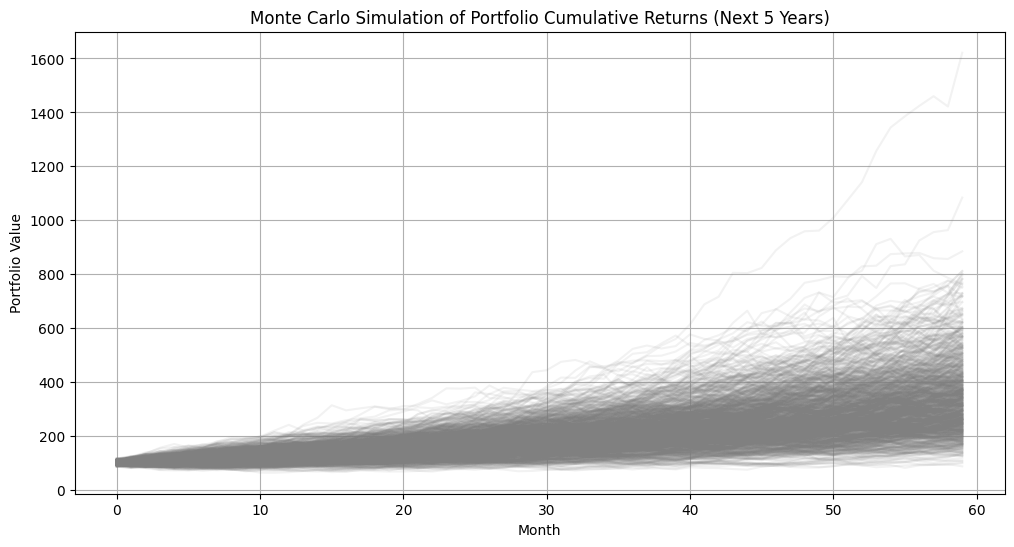

In [31]:
import numpy as np


num_simulations = 1000
num_months = 60  # 5 years


mean_returns = merged_returns.mean()
cov_matrix = merged_returns.cov()


initial_value = 100


sim_results = np.zeros((num_months, num_simulations))

for i in range(num_simulations):
  
    random_returns = np.random.multivariate_normal(mean_returns, cov_matrix, num_months)
 
    portfolio_returns = random_returns.dot(optimal_weights)
   
    cum_values = initial_value * np.cumprod(1 + portfolio_returns / 100)
    sim_results[:, i] = cum_values

plt.figure(figsize=(12,6))
plt.plot(sim_results, color='grey', alpha=0.1)
plt.title('Monte Carlo Simulation of Portfolio Cumulative Returns (Next 5 Years)')
plt.xlabel('Month')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.show()


## Feature Engineering for Machine Learning on AAPL Returns

This section prepares features for time series regression or classification on Apple (AAPL) stock monthly returns:

- **Lagged Returns:** Previous month (`Return_lag_1`) and two months ago (`Return_lag_2`) serve as predictive features.
- **Rolling Mean:** A 3-month moving average (`MA_3`) provides trend context.
- **Target Variable:** The task is to predict the next month's return (`Target`).

This feature set structures the data for applying and evaluating predictive machine learning models.


In [34]:
import pandas as pd


stock = 'AAPL'
df = stock_dfs[stock].copy()


df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

df['Return_lag_1'] = df['Monthly Return (%)'].shift(1)
df['Return_lag_2'] = df['Monthly Return (%)'].shift(2)
df['MA_3'] = df['Monthly Return (%)'].rolling(window=3).mean()

df['Target'] = df['Monthly Return (%)'].shift(-1)

df_ml = df.dropna()

print(df_ml[['Monthly Return (%)', 'Return_lag_1', 'Return_lag_2', 'MA_3', 'Target']].head())


   Monthly Return (%)  Return_lag_1  Return_lag_2      MA_3     Target
2           -1.301162     -0.650847     -5.432073 -2.461361  17.862903
3           17.862903     -1.301162     -0.650847  5.303632  -0.279194
4           -0.279194     17.862903     -1.301162  5.427516 -14.918119
5          -14.918119     -0.279194     17.862903  0.888530 -10.388244
6          -10.388244    -14.918119     -0.279194 -8.528519  -3.986612


## Random Forest Regression for Monthly Return Prediction

Here, a Random Forest model is trained on lagged returns and moving averages to forecast the next month's return.

- The dataset is split into training (70%) and testing (30%) subsets.
- Model performance is evaluated using RMSE (error magnitude) and R² (explained variance).
- This supervised learning approach offers a baseline for predictive modeling of stock returns.


In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


X = df_ml[['Return_lag_1', 'Return_lag_2', 'MA_3']]
y = df_ml['Target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Random Forest RMSE: {mse ** 0.5:.4f}")
print(f"Random Forest R^2 Score: {r2:.4f}")


Random Forest RMSE: 12.2797
Random Forest R^2 Score: -0.1907


## Advanced Feature Engineering with Technical Indicators

This section introduces additional features trusted in technical analysis to improve stock return prediction models:

- **RSI** quantifies momentum and trend strength.
- **20-period SMA** smooths returns capturing trend direction.
- **Bollinger Bands** provide dynamic support/resistance bounds built from volatility.

These features, combined with prior lagged returns and target setup, create a richer dataset for machine learning applications.


In [38]:
import pandas as pd
import numpy as np

# Function to calculate RSI
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Example, use 'AAPL' stock DataFrame as before
df = stock_dfs['AAPL'].copy()
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# Calculate simple moving average and Bollinger Bands
df['SMA_20'] = df['Monthly Return (%)'].rolling(window=20).mean()
df['STD_20'] = df['Monthly Return (%)'].rolling(window=20).std()
df['Upper_BB'] = df['SMA_20'] + (2 * df['STD_20'])
df['Lower_BB'] = df['SMA_20'] - (2 * df['STD_20'])

# Calculate RSI
df['RSI_14'] = calculate_rsi(df['Monthly Return (%)'], 14)

# Lag features and target
df['Return_lag_1'] = df['Monthly Return (%)'].shift(1)
df['Return_lag_2'] = df['Monthly Return (%)'].shift(2)
df['Target'] = df['Monthly Return (%)'].shift(-1)

# Drop rows with NaNs to prepare final ML DataFrame
df_ml = df.dropna(subset=['RSI_14', 'SMA_20', 'Upper_BB', 'Lower_BB', 'Return_lag_1', 'Return_lag_2', 'Target'])

print(df_ml[['Monthly Return (%)', 'RSI_14', 'SMA_20', 'Upper_BB', 'Lower_BB', 'Return_lag_1', 'Return_lag_2', 'Target']].head())


    Monthly Return (%)     RSI_14    SMA_20   Upper_BB   Lower_BB  \
19            7.127214  58.748886  1.241413  21.878140 -19.395314   
20           22.245819  61.947034  2.625308  25.015391 -19.764775   
21           -3.059967  50.297991  2.504852  24.994846 -19.985142   
22          -12.751892  51.780169  1.932315  25.392363 -21.527732   
23           18.811771  54.004023  1.979759  25.578880 -21.619363   

    Return_lag_1  Return_lag_2     Target  
19     12.803540      8.333429  22.245819  
20      7.127214     12.803540  -3.059967  
21     22.245819      7.127214 -12.751892  
22     -3.059967     22.245819  18.811771  
23    -12.751892     -3.059967  -9.901750  


## Random Forest Model with Enhanced Technical Features

The model uses a comprehensive feature set consisting of RSI, moving averages, Bollinger bands, and lagged returns to predict the next monthly return of AAPL stock.

- Data is split into training and test sets to evaluate generalization.
- Random Forest regression is employed to capture nonlinear relationships.
- Performance is measured using RMSE and R², quantifying prediction accuracy and explanatory power.

This approach aims to improve forecasting by leveraging multiple technical indicators.


In [39]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
feature_cols = ['RSI_14', 'SMA_20', 'Upper_BB', 'Lower_BB', 'Return_lag_1', 'Return_lag_2']
X = df_ml[feature_cols]
y = df_ml['Target']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Evaluate predictions
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Enhanced Feature Random Forest RMSE: {mse ** 0.5:.4f}")
print(f"Enhanced Feature Random Forest R^2 Score: {r2:.4f}")


Enhanced Feature Random Forest RMSE: 14.0980
Enhanced Feature Random Forest R^2 Score: -0.1476


## Random Forest Classification for Monthly Return Direction Prediction

This segment reframes the problem as binary classification: predicting whether the next month's return is non-negative (1) or negative (0).

- The enhanced feature set from technical indicators and lags is retained.
- The model is trained and tested on a standard split.
- Performance metrics include accuracy and a classification report highlighting precision, recall, and F1-score.

This formulation supports decision-making on expected price direction rather than exact return magnitude.


In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create binary target: 1 if next month's return >= 0, else 0
df_ml['Target_Class'] = (df_ml['Target'] >= 0).astype(int)

# Features remain the same as before
feature_cols = ['RSI_14', 'SMA_20', 'Upper_BB', 'Lower_BB', 'Return_lag_1', 'Return_lag_2']
X = df_ml[feature_cols]
y = df_ml['Target_Class']

# Split into train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize, train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Classification Accuracy: {accuracy:.4f}")
print(f"Classification Report:\n{report}")


C:\Users\indra\AppData\Local\Temp\ipykernel_1824\1010181498.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml['Target_Class'] = (df_ml['Target'] >= 0).astype(int)


Classification Accuracy: 0.5524
Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.25      0.33        64
           1       0.57      0.80      0.66        79

    accuracy                           0.55       143
   macro avg       0.53      0.52      0.50       143
weighted avg       0.54      0.55      0.52       143



## Handling Class Imbalance with SMOTE

Class imbalance can impair classifier performance by biasing predictions towards the majority class.

SMOTE synthesizes new minority class examples by interpolating between nearby instances, improving class balance in the training set.

Only the training data is resampled to avoid data leakage. The resulting balanced dataset helps the model learn more generalizable decision boundaries.


In [42]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training set class distribution: {y_train.value_counts()}")
print(f"Resampled training set class distribution: {pd.Series(y_train_res).value_counts()}")


Original training set class distribution: Target_Class
1    196
0    136
Name: count, dtype: int64
Resampled training set class distribution: Target_Class
0    196
1    196
Name: count, dtype: int64


## Random Forest Hyperparameter Tuning with GridSearchCV

To optimize classifier performance, GridSearchCV exhaustively searches multiple hyperparameter combinations, validating via 5-fold cross-validation.

- Parameters considered include number of trees, max tree depth, and minimum samples for splits and leaves.
- Accuracy score guides selection of the best performing setup.
- Tuning is conducted on the balanced dataset post-SMOTE to ensure robust minority class modeling.

This systematic approach improves model accuracy and generalization on imbalanced financial time-series data.


In [43]:
from sklearn.model_selection import GridSearchCV

# Parameters grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize classifier
rf = RandomForestClassifier(random_state=42)

# Grid search with 5-fold CV
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_res, y_train_res)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation accuracy: 0.6024


## Evaluating Tuned Random Forest Model on Test Data

The best hyperparameter configuration from GridSearchCV is used to evaluate model performance on unseen test data.

- Predictive accuracy, along with precision, recall, and F1-score for each class, are reported.
- This step provides an unbiased assessment of the classifier’s effectiveness after tuning and resampling.
- Results here indicate how well the model is likely to perform in real-world return direction prediction.


In [44]:
# Use best estimator to predict on test set
best_rf = grid_search.best_estimator_
y_pred_test = best_rf.predict(X_test)

accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Tuned Model Test Accuracy: {accuracy_test:.4f}")
print(classification_report(y_test, y_pred_test))


Tuned Model Test Accuracy: 0.4965
              precision    recall  f1-score   support

           0       0.43      0.39      0.41        64
           1       0.54      0.58      0.56        79

    accuracy                           0.50       143
   macro avg       0.49      0.49      0.49       143
weighted avg       0.49      0.50      0.49       143



## Final Project Summary

### Objective
The goal of this project was to build a comprehensive stock market portfolio analysis and predictive modeling framework. It aimed to analyze historical stock performance across various sectors, optimize portfolio allocations, assess risk, and explore machine learning models to predict monthly return directions.

### Data and Methodology
Monthly stock price and volume data from a diversified set of stocks across technology, finance, healthcare, consumer goods, and energy sectors were collected. Key financial metrics such as monthly returns, volatility, and moving averages were calculated. Portfolio analytics included Sharpe ratio calculation, drawdown and Monte Carlo simulations, and performance during market crises were examined. For predictive modeling, both regression and classification approaches using Random Forest models were applied with enhanced technical indicator features. Class imbalance was addressed using SMOTE with hyperparameter tuning performed to optimize model parameters.

### Key Findings
- Portfolio optimization yielded improved risk-adjusted performance compared to equal-weight allocation.
- Drawdown and risk metrics provided realistic insights into downside exposure, including stress scenarios like the 2008 Financial Crisis and COVID-19 crash.
- Monte Carlo simulations illustrated a range of future portfolio value trajectories, emphasizing uncertainty in returns.
- The machine learning classification model to predict stock return directions achieved around 50% accuracy, highlighting the difficulty of this task given noisy financial data and complexity of markets.
  
### Challenges
- Financial time series prediction is intrinsically complex due to market volatility, external factors, and noisy data.
- Limited granularity (monthly data) and available features constrained the predictive performance.
- Class imbalance posed challenges, successfully mitigated using SMOTE but with room for model improvement.

### Future Work
- Incorporate higher frequency data (daily/weekly) and additional fundamental and macroeconomic indicators.
- Explore alternative modeling techniques including gradient boosting, deep learning, and sequence models (LSTM).
- Extend portfolio analysis with backtesting and real-time strategy implementation.
- Enhance feature engineering and experiment with ensemble methods and feature selection.

### Final Thoughts
This project demonstrates a robust, end-to-end quantitative finance pipeline integrating data analysis, portfolio optimization, and machine learning. While prediction remains challenging, the project provides valuable foundational skills and realistic insights crucial for progressing in data-driven investment and quantitative finance roles.


## References

- Data sourced from [Stooq.com](https://stooq.com/), providing historical stock prices for AAPL, MSFT, GOOGL, NVDA, JPM, BAC, GS, JNJ, PFE, UNH, AMZN, WMT, KO, XOM, CVX, and SPY.
- Portfolio analysis and metrics inspired by:
    - Bodie, Zvi, Alex Kane, and Alan J. Marcus. *Investments*. McGraw-Hill Education, 2014.
    - [Modern Portfolio Theory - Investopedia](https://www.investopedia.com/terms/m/modernportfoliotheory.asp)
- Technical indicator formulas:
    - [Relative Strength Index (RSI) - Investopedia](https://www.investopedia.com/terms/r/rsi.asp)
    - [Bollinger Bands - Investopedia](https://www.investopedia.com/terms/b/bollingerbands.asp)
- Risk and drawdown analytics:
    - [Sharpe Ratio - Investopedia](https://www.investopedia.com/terms/s/sharperatio.asp)
    - [Maximum Drawdown - Corporate Finance Institute](https://corporatefinanceinstitute.com/resources/valuation/maximum-drawdown/)
- Machine Learning model references:
    - Géron, Aurélien. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O’Reilly Media, 2019.
    - [Scikit-learn documentation](https://scikit-learn.org/stable/user_guide.html)
    - [imbalanced-learn documentation (SMOTE)](https://imbalanced-learn.org/stable/over_sampling.html#smote-adasyn)
- Project design inspired by frameworks at:
    - [How to Frame Real Data Problems](https://www.notion.so/)
    - [The Ultimate Markdown Cheat Sheet - Kaggle](https://www.kaggle.com/code/jeffd23/markdown-cheatsheet)

